# 🏥 Fine-tuning LoRA — Modèle médical expérimental (TechCorp Industries)**Mission Expérimentale — Filière IA — VERSION CORRIGÉE v2**Ce notebook fine-tune **Phi-3.5-mini-Instruct** en **QLoRA (4-bit)** sur le dataset médical public[`ruslanmv/ai-medical-chatbot`](https://huggingface.co/datasets/ruslanmv/ai-medical-chatbot).⚠️ **Modèle expérimental — non destiné à la production.** Ne remplace jamais l'expertise médicale humaine.## 🛠️ Correctifs apportés par rapport à la version précédenteLa première tentative a produit un modèle générant du texte incohérent (loss bloquée ~7.7,sortie type "to I I, my it of."). Diagnostic : une boucle de "sécurité" convertissantmanuellement les poids bfloat16 → float16 couche par couche a cassé le **weight tying**(partage de poids entre la couche d'embedding et la couche de sortie `lm_head`), corrompantla capacité du modèle à produire du texte cohérent. Cette version corrige le problème en :- Utilisant **bf16 de bout en bout** (chargement du modèle, quantization, entraînement) au lieu  d'un mélange fp16/bf16 nécessitant des bidouilles manuelles- **Suppression totale** de la boucle de conversion manuelle des poids- Cohérence stricte entre `bnb_4bit_compute_dtype`, `torch_dtype` et `bf16` dans `SFTConfig`**Avant de lancer : Exécution → Modifier le type d'exécution → GPU (T4)**

## 1. Installation des dépendances

In [1]:
!pip install -q -U "transformers>=4.46.0" "accelerate>=1.2.0" "peft>=0.13.0" "bitsandbytes>=0.45.0" datasets "trl>=0.12.0" huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.2 MB/s eta 0:00:00


## 2. Authentification Hugging Face (optionnel mais recommandé)

In [3]:
import os
from huggingface_hub import login
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print("Connecté via HF_TOKEN")
else:
    try:
        login()
        print("Connecté via login interactif")
    except Exception:
        print("Pas de connexion HF — on continue sans (dataset et modèle sont publics)")

Connecté via login interactif


## 3. Vérification du GPU

In [5]:
import torch
print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device :", torch.cuda.get_device_name(0))
    print("VRAM totale :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "Go")
    print("Support bf16 natif :", torch.cuda.is_bf16_supported())
else:
    raise RuntimeError("Aucun GPU détecté. Va dans Exécution > Modifier le type d'exécution > GPU.")

GPU disponible : True
Device : Tesla T4
VRAM totale : 15.6 Go
Support bf16 natif : True


## 4. Chargement du dataset médical (Hugging Face)

In [6]:
from datasets import load_dataset
raw_dataset = load_dataset("ruslanmv/ai-medical-chatbot")
print(raw_dataset)
print()
print("Colonnes :", raw_dataset["train"].column_names)
print()
print("Exemple brut :")
print(raw_dataset["train"][0])

README.md:   0%|          | 0.00/863 [00:00<?, ?B/s]

dialogues.parquet:   0%|          | 0.00/142M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/256916 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Description', 'Patient', 'Doctor'],
        num_rows: 256916
    })
})

Colonnes : ['Description', 'Patient', 'Doctor']

Exemple brut :
{'Description': 'Q. What does abutment of the nerve root mean?', 'Patient': 'Hi doctor,I am just wondering what is abutting and abutment of the nerve root means in a back issue. Please explain. What treatment is required for\xa0annular bulging and tear?', 'Doctor': 'Hi. I have gone through your query with diligence and would like you to know that I am here to help you. For further information consult a neurologist online -->'}


## 5. Nettoyage, dé-duplication et mise en forme du datasetConformément au rapport de qualité des données (filière DATA), on applique : dé-duplication desquestions patient, filtrage des réponses médecin trop courtes pour être exploitables (< 20caractères), puis sous-échantillonnage et formatage au template Phi-3.5 Instruct.

In [7]:
import pandas as pd
df = raw_dataset["train"].to_pandas()
print("Dataset brut :", len(df), "entrées")
df = df.drop_duplicates(subset=["Patient"])
print("Après dé-duplication :", len(df), "entrées")
df = df[df["Doctor"].str.len() >= 20]
print("Après filtrage qualité (réponses < 20 caractères exclues) :", len(df), "entrées")
SAMPLE_SIZE = 1000
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)
print("Échantillon retenu pour l'entraînement :", len(df_sample), "entrées")
def format_example(row):
    patient = (row["Patient"] or "").strip()
    doctor = (row["Doctor"] or "").strip()
    description = (row["Description"] or "").strip()
    instruction = patient if patient else description
    response = doctor
    text = (
        "<|system|>\nYou are a medical assistant providing general health information. "
        "This is an experimental model and does not replace professional medical advice.<|end|>\n"
        f"<|user|>\n{instruction}<|end|>\n"
        f"<|assistant|>\n{response}<|end|>"
    )
    return text
df_sample["text"] = df_sample.apply(format_example, axis=1)
from datasets import Dataset
formatted_dataset = Dataset.from_pandas(df_sample[["text"]])
formatted_dataset = formatted_dataset.filter(lambda x: len(x["text"]) > 0)
print(f"Exemples valides après filtrage final : {len(formatted_dataset)}")
print()
print(formatted_dataset[0]["text"][:500])

Dataset brut : 256916 entrées
Après dé-duplication : 246006 entrées
Après filtrage qualité (réponses < 20 caractères exclues) : 245951 entrées
Échantillon retenu pour l'entraînement : 1000 entrées


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Exemples valides après filtrage final : 1000

<|system|>
You are a medical assistant providing general health information. This is an experimental model and does not replace professional medical advice.<|end|>
<|user|>
Sir,my father takes an insugen insulin 30/70 28-20 at morning and day resp.but his sugar legal is not constant and it fluxuate very much.He is also a patient of heart and kidney.his s.creatnine is 4.89.the doctor always advised us to contol sugar level.How can we do this.We do all according to doctor.<|end|>
<|assistant|>
cre


## 6. Split train / validation

In [9]:
split_dataset = formatted_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]
print("Exemples d'entraînement :", len(train_dataset))
print("Exemples de validation :", len(eval_dataset))

Exemples d'entraînement : 900
Exemples de validation : 100


## 7. Chargement du modèle de base en 4-bit (QLoRA) — bf16 cohérent de bout en bout⚠️ **Correctif principal :** plus aucune conversion manuelle de poids après chargement.Tout est en `bfloat16`, supporté nativement par le GPU T4.

In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
MODEL_NAME = "microsoft/Phi-3.5-mini-instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
)
model.config.use_cache = False
print("Modèle chargé en 4-bit (bf16 cohérent, aucune conversion manuelle de poids)")

config.json:   0%|          | 0.00/3.45k [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json:   0%|          | 0.00/3.98k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Modèle chargé en 4-bit (bf16 cohérent, aucune conversion manuelle de poids)


## 8. Configuration LoRA (PEFT)On entraîne uniquement de petits adaptateurs de rang faible, insérés sur les couches d'attention —environ 1% des paramètres totaux du modèle sont entraînés.

In [13]:
from peft import LoraConfig, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
print("Config LoRA prête (r=16, alpha=32)")

Config LoRA prête (r=16, alpha=32)


## 9. Configuration de l'entraînement — bf16 cohérentDifférence clé avec la version précédente : `bf16=True` (au lieu de `fp16=False, bf16=False`,qui désactivait toute précision mixte et empêchait une vraie convergence).

In [15]:
from trl import SFTTrainer, SFTConfig
training_args = SFTConfig(
    output_dir="./phi3.5-medical-lora",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="epoch",
    fp16=False,
    bf16=True,
    report_to="none",
    dataset_text_field="text",
    max_length=1024,
    packing=False,
)
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=lora_config,
    processing_class=tokenizer,
)
trainer.model.print_trainable_parameters()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/900 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

trainable params: 3,145,728 || all params: 3,824,225,280 || trainable%: 0.0823


## 10. Lancement du fine-tuning⏱️ Sur un GPU T4 gratuit, compter environ 45 à 90 minutes pour 2 épochs sur ~900 exemples.Surveille la **loss d'entraînement** : elle doit décroître nettement (idéalement passer sous 2.0après quelques dizaines de steps). Si elle reste bloquée au-dessus de 5-6 après 50 steps,arrête et signale-le — ce serait le signe d'un nouveau problème.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
train_result = trainer.train()

Manque de temps pour réalisé cette partie et de la génération du rapport de livrable, le lancement de cette celulle a commencé aux alentours de 15h40 puis arrêté car prenant trop de temps (voir l'image)

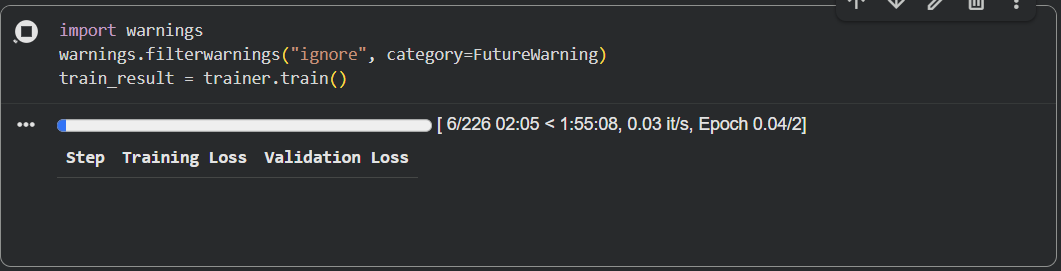

## 11. Sauvegarde des adaptateurs LoRA

In [ ]:
trainer.save_model("./phi3.5-medical-lora-final")
tokenizer.save_pretrained("./phi3.5-medical-lora-final")
print("Adaptateurs LoRA sauvegardés dans ./phi3.5-medical-lora-final")

## 12. Export des métriques d'entraînement (loss, epochs)

In [ ]:
from IPython.display import display
log_history = trainer.state.log_history
metrics_df = pd.DataFrame(log_history)
metrics_df.to_csv("training_metrics.csv", index=False)
print("Résumé des métriques d'entraînement :")
display_cols = [c for c in ["step", "loss", "eval_loss", "epoch"] if c in metrics_df.columns]
display(metrics_df[display_cols])
train_logs = [m for m in log_history if "loss" in m and "eval_loss" not in m]
eval_logs = [m for m in log_history if "eval_loss" in m]
final_train_loss = train_logs[-1]["loss"] if train_logs else None
final_eval_loss = eval_logs[-1]["eval_loss"] if eval_logs else None
first_train_loss = train_logs[0]["loss"] if train_logs else None
print()
if first_train_loss is not None:
    print(f"Loss d'entraînement initiale : {first_train_loss:.4f}")
if final_train_loss is not None:
    print(f"Loss d'entraînement finale : {final_train_loss:.4f}")
if final_eval_loss is not None:
    print(f"Loss de validation finale : {final_eval_loss:.4f}")
print(f"Nombre d'épochs : {training_args.num_train_epochs}")
print(f"Nombre d'exemples d'entraînement : {len(train_dataset)}")
if final_train_loss is not None and first_train_loss is not None:
    if final_train_loss < first_train_loss * 0.7:
        print("\n✅ La loss a significativement diminué — le modèle a bien appris.")
    else:
        print("\n⚠️ La loss n'a pas beaucoup diminué — vérifier la configuration avant de continuer.")

## 13. Visualisation de la courbe de loss

In [ ]:
import matplotlib.pyplot as plt
train_steps = [m["step"] for m in log_history if "loss" in m and "eval_loss" not in m]
train_losses = [m["loss"] for m in log_history if "loss" in m and "eval_loss" not in m]
eval_steps = [m["step"] for m in log_history if "eval_loss" in m]
eval_losses = [m["eval_loss"] for m in log_history if "eval_loss" in m]
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Training loss", marker="o")
if eval_losses:
    plt.plot(eval_steps, eval_losses, label="Validation loss", marker="s")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Courbe de loss — Fine-tuning LoRA Phi-3.5 médical (v2 corrigée)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Test du modèle fine-tunéSi les correctifs ont fonctionné, les réponses doivent être du texte cohérent et grammaticalementcorrect (même si le contenu médical reste à valider par un professionnel).

In [ ]:
test_questions = [
    "I have had a persistent headache and mild fever for two days. What could be the cause?",
    "What are the common symptoms of seasonal allergies?",
    "What should I do if I think I have a sprained ankle?",
]
test_responses = []
trainer.model.eval()
for question in test_questions:
    prompt = (
        "<|system|>\nYou are a medical assistant providing general health information. "
        "This is an experimental model and does not replace professional medical advice.<|end|>\n"
        f"<|user|>\n{question}<|end|>\n<|assistant|>\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(trainer.model.device)
    with torch.no_grad():
        outputs = trainer.model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.5,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=False,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    test_responses.append(response.strip())
    print("=" * 80)
    print("Q:", question)
    print("R:", response.strip())
    print()

## 15. ⚠️ Rappel — Limites du modèle expérimental- Ce modèle est **expérimental** et n'est **pas destiné à un déploiement en production**.- Il **ne remplace jamais l'expertise médicale humaine**.- Une **validation par des professionnels de santé qualifiés** serait obligatoire avant tout usage réel.

## 16. Génération automatique du rapport livrable

In [ ]:
report_content = f"""=================================================================RAPPORT LIVRABLE 2 - Modèle Médical Expérimental (LoRA) - VERSION CORRIGÉE=================================================================1. INFORMATIONS GÉNÉRALES---------------------------------- Modèle de base : Microsoft Phi-3.5-mini-instruct (QLoRA 4-bit, bf16 cohérent)- Dataset utilisé : ruslanmv/ai-medical-chatbot (dé-dupliqué, filtré qualité)- Nombre d'exemples d'entraînement : {len(train_dataset)}- Nombre d'exemples de validation : {len(eval_dataset)}- Nombre d'époques : {training_args.num_train_epochs}2. PERFORMANCES D'ENTRAÎNEMENT---------------------------------- Loss d'entraînement initiale : {first_train_loss if first_train_loss else 'N/A'}- Loss d'entraînement finale : {final_train_loss if final_train_loss else 'N/A'}- Loss de validation finale : {final_eval_loss if final_eval_loss else 'N/A'}3. TESTS DE GÉNÉRATION (PERFORMANCES DU MODÈLE)---------------------------------"""
for i, (q, r) in enumerate(zip(test_questions, test_responses)):
    report_content += f"\nQUESTION {i+1}: {q}\n"
    report_content += f"RÉPONSE DU MODÈLE:\n{r}\n"
    report_content += "-" * 40 + "\n"
report_content += "\n\nAvertissement : Modèle expérimental, ne remplace pas un avis médical humain.
with open("Rapport_Medical_Livrable2_v2.txt", "w", encoding="utf-8") as f:
    f.write(report_content)
print("✅ Rapport généré : Rapport_Medical_Livrable2_v2.txt")
from google.colab import files
files.download("Rapport_Medical_Livrable2_v2.txt")
files.download("training_metrics.csv")
files.download("loss_curve.png")